# 🚀 Day 4 — Probability in Cricket (Now with Conditional Probability)

India needs:

👉 30 runs in 12 balls

At first, chances may look 50-50…

But after every ball:
👉 The probability changes

This is called **Conditional Probability**

In this notebook:
👉 We simulate matches  
👉 And update winning chances ball-by-ball

## 💡 Key Concept

Probability is NOT fixed.

👉 It updates when new information comes

Example:
- Before ball → 50%
- After SIX → higher probability
- After DOT ball → lower probability

In [2]:
import random
import numpy as np

runs_needed = 30
balls = 12

outcomes = [0,1,2,3,4,5]


## Match Simulation Function

In [21]:
def simulate_match(runs_to_win, balls):
    runs = 0
    for _ in range(balls):
        score = random.choice(outcomes)
        runs +=  score
        if runs >= runs_to_win:
            return "Win"
    return "Loss"

## Initial Probability

In [24]:
def estimate_probabilty(target, balls, simulate=1000):
    probabilities = []
    for _ in range(simulate):
        probabilities.append(simulate_match(target, balls))

    win_cnt = probabilities.count("Win")
    return win_cnt/len(probabilities)

In [29]:
print(estimate_probabilty(30, 12))

0.519


## Conditional Probability (Ball-by-Ball)

In [47]:
history = []

target = 30
balls_left = 12

for ball in range(1,13):
    run = random.choice(outcomes)
    target -= run
    balls_left -= 1

    if target > 0 and balls_left > 0:
        prob = estimate_probabilty(target, balls_left, 500)
    else:
        prob = 1.0 if target <= 0 else 0.0

    history.append([ball, target, run, balls_left, prob])
    print(f'Ball {ball}, run {run}, balls_left {balls_left}, target {target}, Probability {prob:.2f}')
    

    if target <= 0:
        print("Match Win")
        break
    if target > 0 and balls_left == 0:
        print("Match Lost")

Ball 1, run 1, balls_left 11, target 29, Probability 0.43
Ball 2, run 5, balls_left 10, target 24, Probability 0.61
Ball 3, run 0, balls_left 9, target 24, Probability 0.42
Ball 4, run 4, balls_left 8, target 20, Probability 0.53
Ball 5, run 0, balls_left 7, target 20, Probability 0.33
Ball 6, run 4, balls_left 6, target 16, Probability 0.49
Ball 7, run 4, balls_left 5, target 12, Probability 0.60
Ball 8, run 0, balls_left 4, target 12, Probability 0.36
Ball 9, run 1, balls_left 3, target 11, Probability 0.15
Ball 10, run 3, balls_left 2, target 8, Probability 0.17
Ball 11, run 4, balls_left 1, target 4, Probability 0.35
Ball 12, run 2, balls_left 0, target 2, Probability 0.00
Match Lost


## 🤯 Insight

After every ball:

👉 Runs needed changes  
👉 Balls left changes  
👉 Probability updates  

This is **Conditional Probability**:

👉 P(Win | current situation)

## 💡 Final Learning

Probability is dynamic.

👉 Every new event changes the outcome  

This is exactly how:

👉 Cricket predictions work  
👉 AI models update predictions  
👉 Real-world decisions are made  

AI doesn't say:
👉 “This will happen”

It says:
👉 “This is most likely right now”

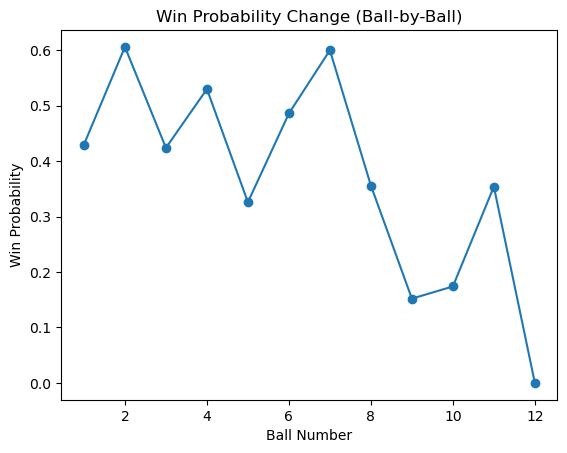

In [48]:
import matplotlib.pyplot as plt

balls = [h[0] for h in history]
probs = [h[4] for h in history]

plt.plot(balls, probs, marker='o')
plt.xlabel("Ball Number")
plt.ylabel("Win Probability")
plt.title("Win Probability Change (Ball-by-Ball)")
plt.show()